## 1. The cosmological model

Sabiendo que $H(z)$ se puede escribir en términos de las abundancias del universo, dada una cosmología, entonces:

\begin{equation}
    H(z) = H_0\sqrt{\Omega_{R,0}(1 + z)^4 + \Omega_{M,0}(1 + z)^3 + \Omega_{\Lambda,0}},
\end{equation}

donde, respectivamente, $\Omega_{R, M, \Lambda}$ representa a las abundancias de radiación, materia y energía osbcura.

La cosmología particular descrita está dada por: $\Omega_{M,0} = 0.3$, $\Omega_{\Lambda,0} = 0.7$ y $H_0 = 100h\,\mathrm{km\, s^{-1}\, Mpc^{-1}}$, donde $h = 0.7$. Entonces, la forma que toma la tasa de expansión es:

\begin{align}
    H(z) 
    &= (70\,\mathrm{km\, s^{-1}\, Mpc^{-1}})\sqrt{\Omega_{R,0}(1 + z)^4 + (0.3)(1 + z)^3 + 0.7}, \\
    &= (70\,\mathrm{km\, s^{-1}\, Mpc^{-1}})\sqrt{(0.3)(1 + z)^3 + 0.7},
\end{align}

recordando que $\sum_i \Omega_i = 1$.

1. Tanto la función raíz cuadrada como el polinomio del radicando son funciones monótonas creacientes, por lo que el comportamiente depende únicamente del redshift $z$. Físicamente, sabemos que $z$ mide pasados próximos a hoy en día con valores pequeños y pasados lejanos a hoy en día con valores grandes, por lo tanto, el el comportamiento esperado de $H(z)$ es que muestre valores más grandes para $z$ cada vez más grandes.
2. Para $z \approx 0.32$, ambas componentes igualan sus contrinuciones; para valores grandes de $z$, la componente dominante es la materia.
3. El ejemplo que se está tratando es el de un fotón que viaja desde una galaxia lejana hasta nosotros, el observador. Si consideramos que existen $t_\text{em}$ y $t_\text{obs}$ y éste último son tiempos tardios, que corresponden a un $z \approx 0$, entonces la componente que domina es la energía obscura, que corresponde a la expansión del universo.

## 2. A photon emitted at high redshift

### 2.1. When was the photon emitted?

La relación del *lookback time* se consigue derivando la expresión $a(z) = (1 + z)^{-1}$ e integrando desde $z_\text{em}$ hasta $z_\text{obs}$, por lo tanto:

1. No, estos dos tiempos son distintos.
2. El tiempo de viaje no es tan sencillo como decir $t = D_C/c$, donde $D_C$ es la distancia comóvil, en cambio, esto es el tiempo comóvil $\tau$. El tiempo físico real que tarda en recorrer todo el espacio hasta nosotros debe ir afectado por un factor de escala debido a la expansión del univeso y eso se ve reflejado con el factor $(1 + z)^{-1}$ que aparece en la expresión de $t_\text{LB}(z)$.

In [196]:
import numpy as np
import matplotlib.pyplot as plt

def simpson(f, a, b, n):
    """
    Parameters:
        f: function to integrate
        a: lower limit of integration
        b: upper limit of integration
        n: number of subintervals (must be multiple of 3)
    """
    if n % 3 != 0:
        raise ValueError("n must be multiple of 3")
    
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)

    mask = np.array(range(3, n, 3)) # Todos los multiplos de 3, salvo los extremos

    y = f(x)
    S = y[0] + 3 * np.sum(np.delete(y, mask)[1:-1]) + 2 * np.sum(y[mask]) + y[-1]

    return S * 3 * h / 8

En términos de la cosmología dada, la expresión a integrar del *lookback time* es:

\begin{align}
    t_\text{LB} 
    &= \frac{1}{(70\,\mathrm{km\, s^{-1}\, Mpc^{-1}})} \int_0^{z_\text{em}}\frac{dz}{(1 + z)\sqrt{(0.3)(1 + z)^3 + 0.7}} \\
    &\approx (13.97\,\mathrm{Gyr}) \int_0^{z_\text{em}}\frac{dz}{(1 + z)\sqrt{(0.3)(1 + z)^3 + 0.7}}.
\end{align}

tLB(z=3) = 11.3528 Gyr


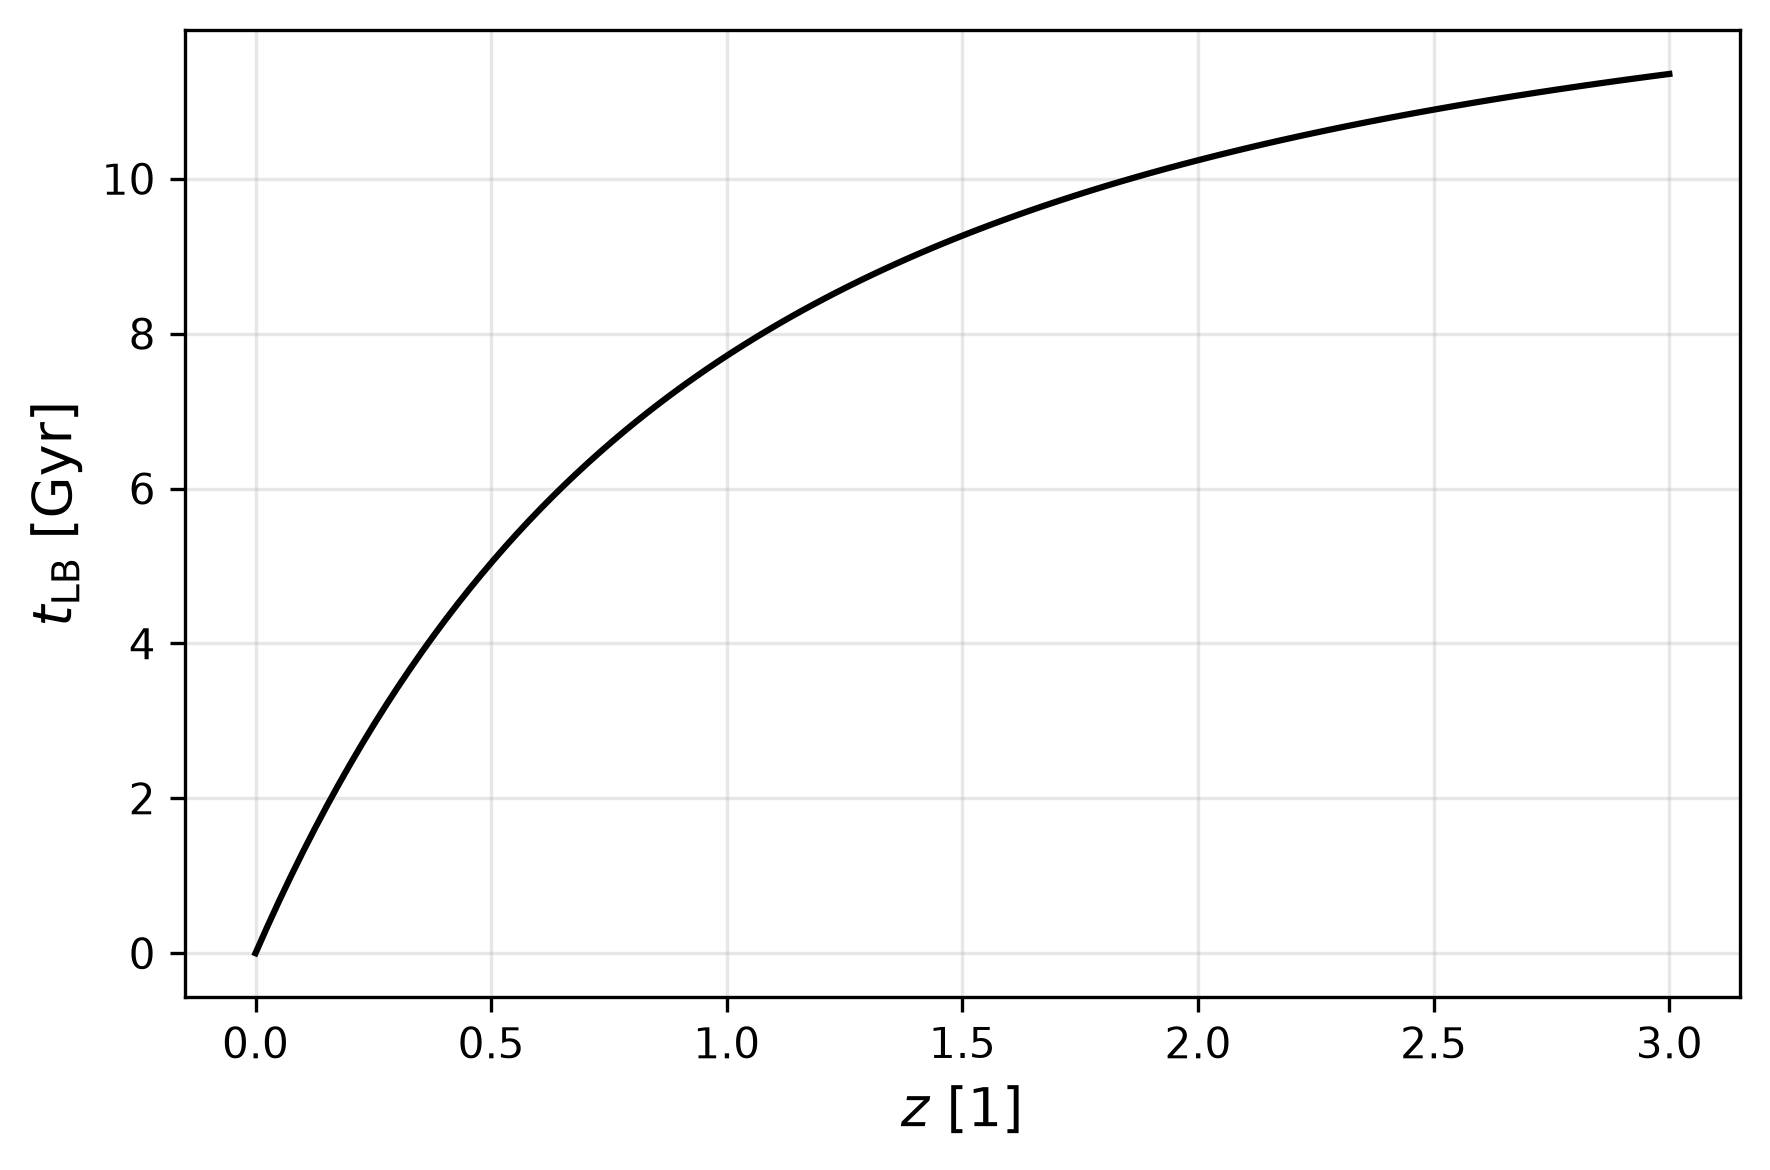

In [197]:
Om0 = 0.3
Ol0 = 0.7
Or0 = 0.0

c = 0.3066 # [c] = Gpc Gyr-1
h = 0.7
H0 = 0.0716 # [H0] = Gyr-1

steps = 30000

def itLB(z):
    d = H0 * (1 + z) * np.sqrt(Om0 * (1 + z) ** 3 + Ol0)
    return 1 / d

z_arr = np.linspace(0, 3, 120)
tLB_arr = np.array([simpson(itLB, 0, z, steps) for z in z_arr])
tLB_z3 = simpson(itLB, 0, 3, steps)

print(f"tLB(z=3) = {tLB_z3:.4f} Gyr")

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(z_arr, tLB_arr, "k-", lw=1.5)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel(r"$t_{\mathrm{LB}}$ [Gyr]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En particular  $t_\text{LB}(z = 3) \approx 11.3528\,\mathrm{Gyr}.$

### 2.2. How far has the photon travelled?

La respuesta corta a la pregunta acerca de la igualdad entre distancia comóvil y el *lookback time* multiplicado por la velocidad es no. La respuesta larga fue contestada arriba, pero aquí se puede realizar una gráfica para comprender el grado en el que difieren. Lo primero es escribir la distancia comóvil de una forma conveniente

\begin{align}
    D_C(z)
    &= \frac{c}{100h\,\mathrm{km\, s^-1\, Mpc^{-1}}} \int_0^{z_\text{em}}\frac{dz}{\sqrt{(0.3)(1 + z)^3 + 0.7}}, \\
    &\approx 2.9979\, \mathrm{Gpc\, h^{-1}} \int_0^{z_\text{em}}\frac{dz}{\sqrt{(0.3)(1 + z)^3 + 0.7}}.
\end{align}

D_C(z=3) = 4.4489 Gpc/h


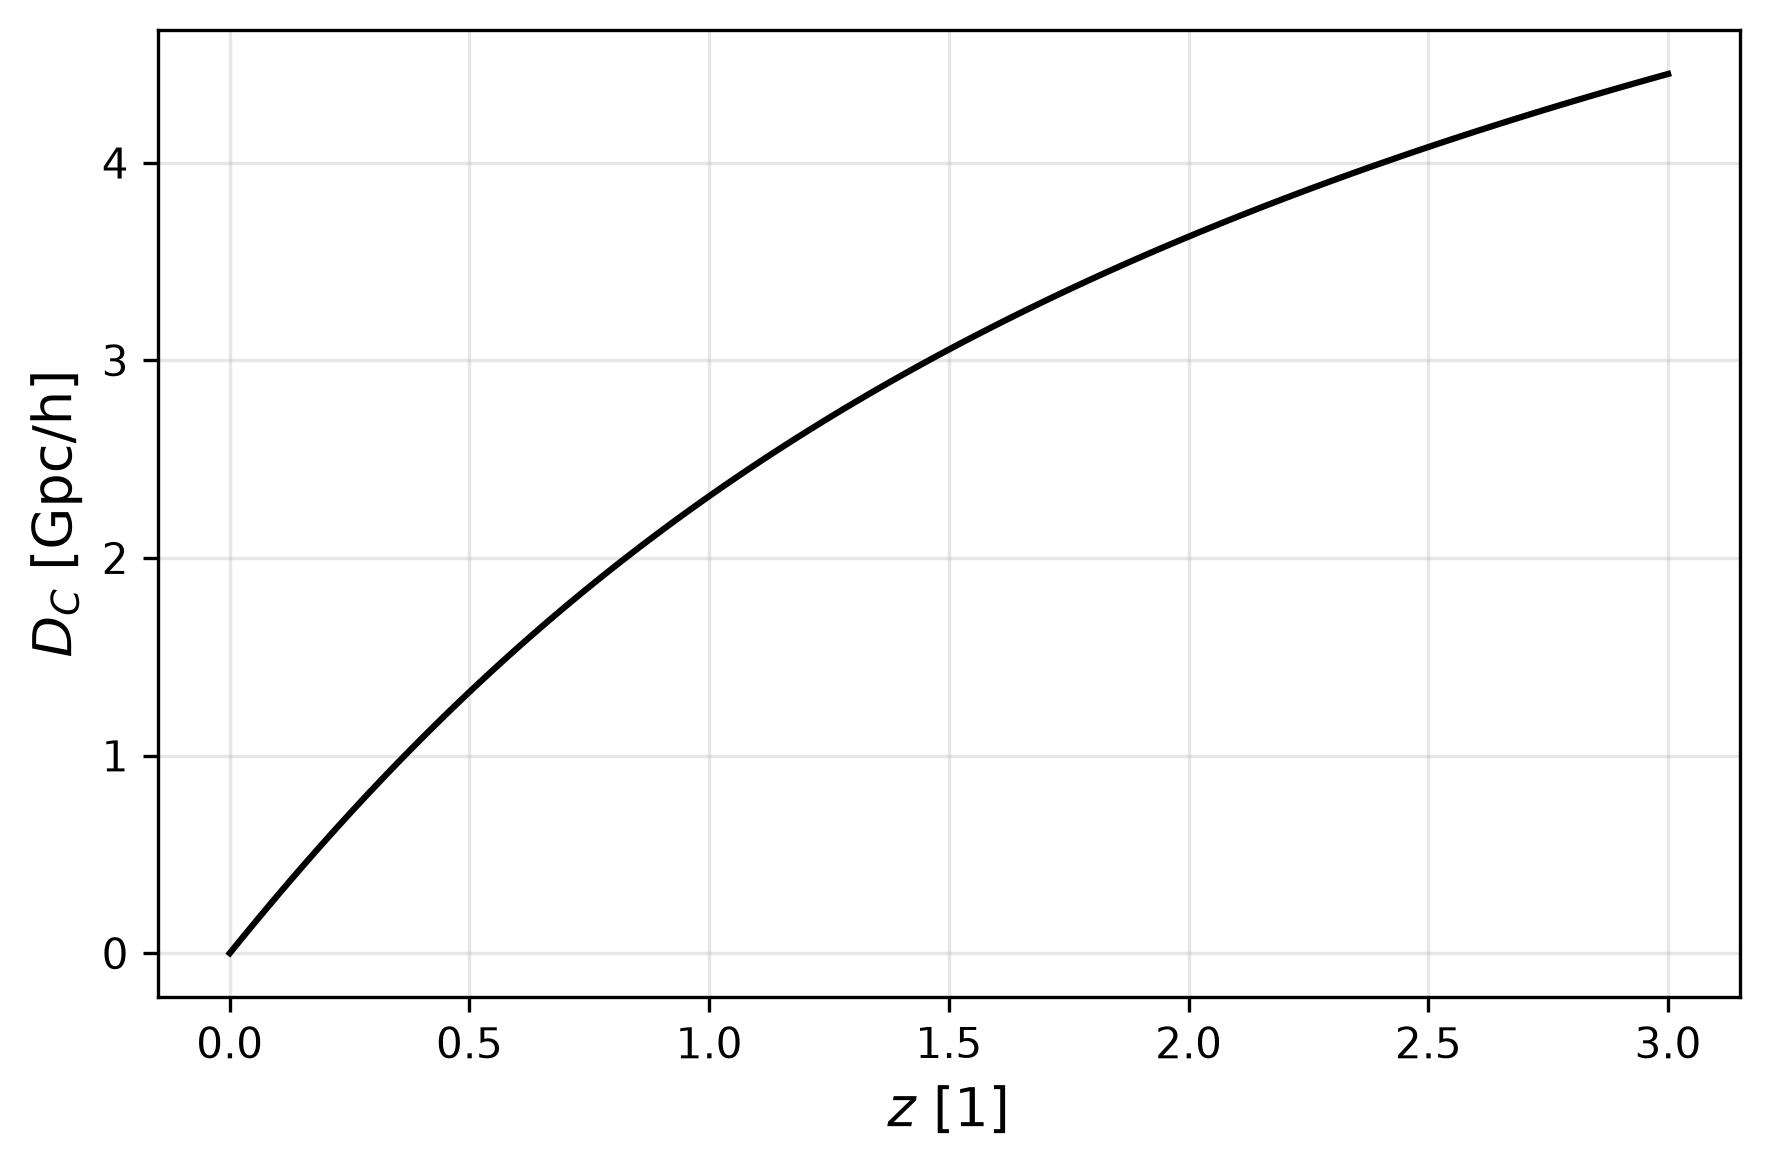

In [198]:
def idc(z):
    n = 2.9979 # [c/H0] = Gpc h-1
    d = np.sqrt(Om0 * (1 + z) ** 3 + Ol0)
    return n / d

dc_arr = np.array([simpson(idc, 0, z, steps) for z in z_arr])
dc_z3 = simpson(idc, 0, 3, steps)

print(f"D_C(z=3) = {dc_z3:.4f} Gpc/h")

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(z_arr, dc_arr, "k-", lw=1.5)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel(r"$D_C$ [Gpc/h]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En particular, el valor en $z = 3$ es: $D_C(z = 3) \approx 4.4489\,\mathrm{Gpc\, h^{-1}}$.

Por otro lado, sabiendo que $c = 0.3066\, \mathrm{Gpc/Gyr}$, se tiene que $ct_\text{LB}(z = 3) \approx 3.4808\, \mathrm{Gpc}$ y $D_C(z = 3) \approx 3.1142\, \mathrm{Gpc}$, por lo que las distancias medidas son distintas.

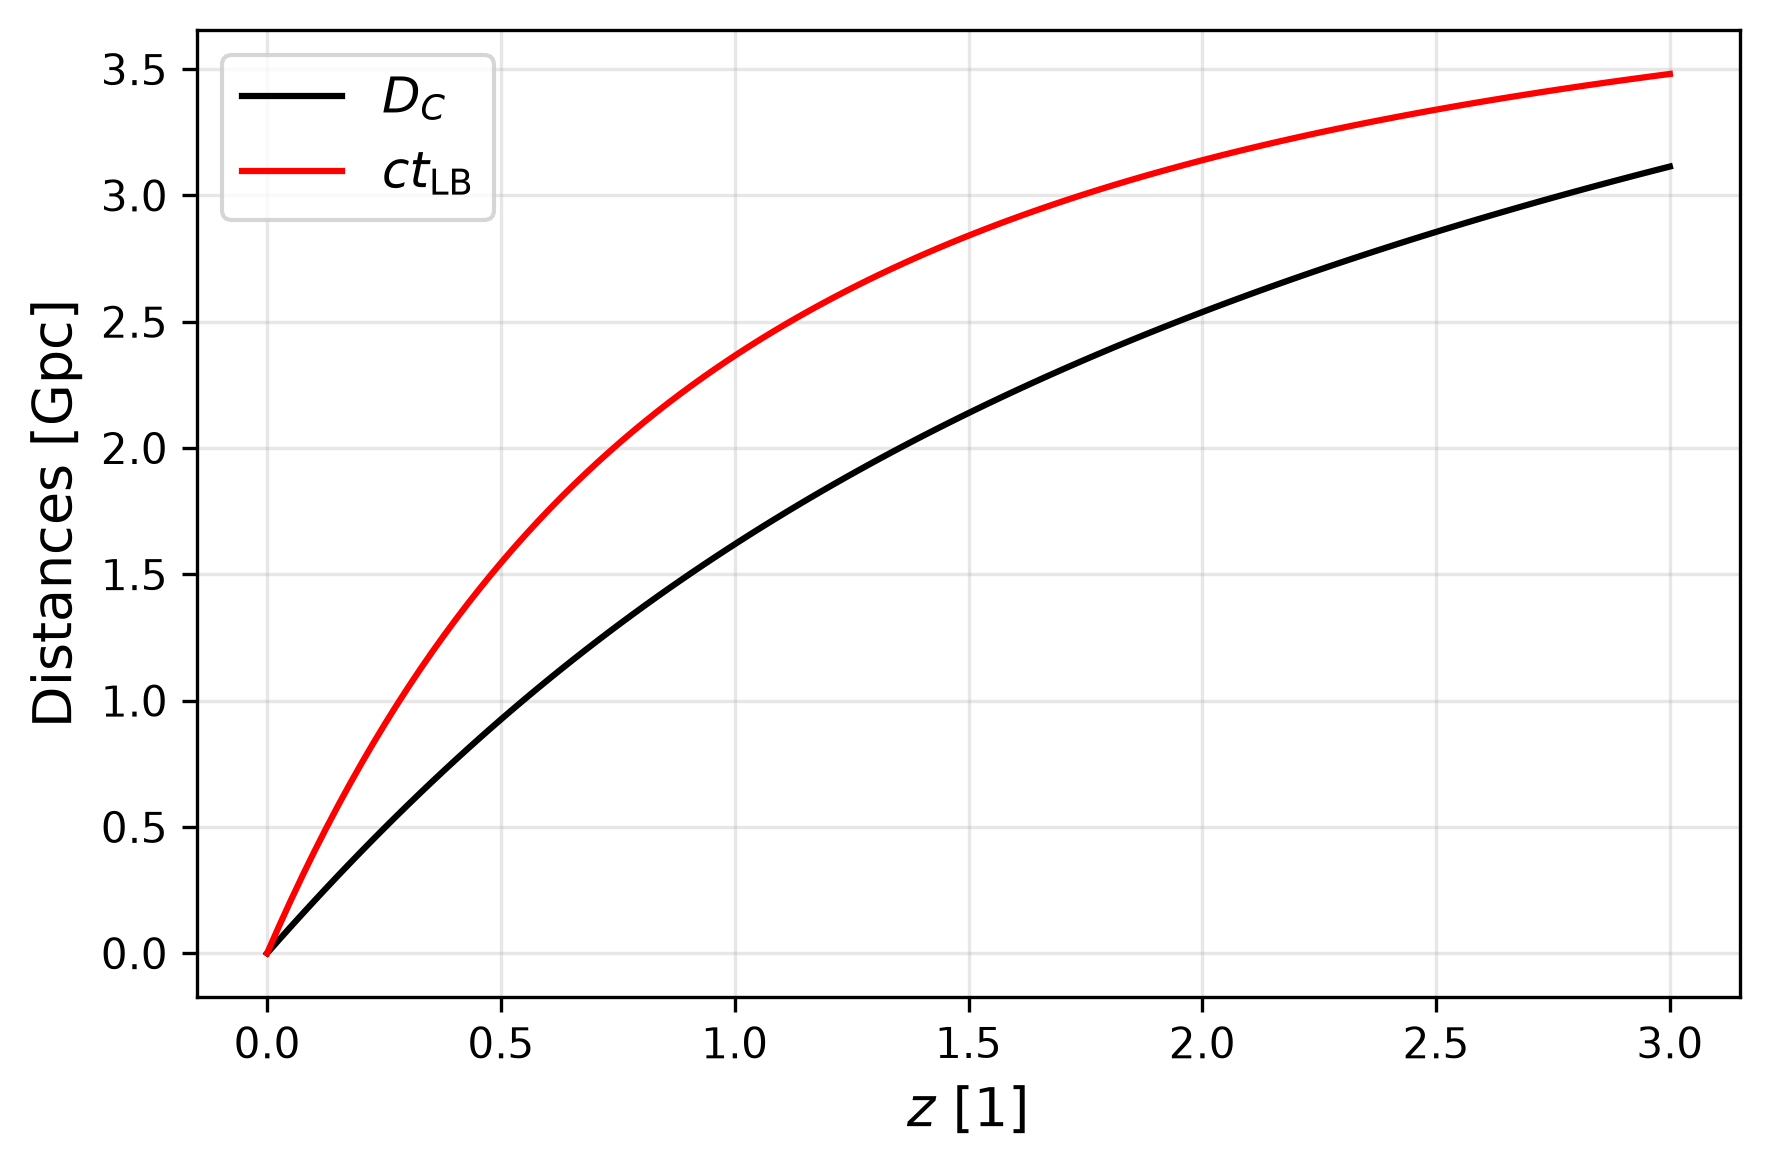

In [199]:
dc_gpc = h * dc_arr
tLB_gpc = c * tLB_arr

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(z_arr, dc_gpc, "k-", lw=1.5, label=r"$D_C$")
plt.plot(z_arr, tLB_gpc, "r-", lw=1.5, label=r"$ct_{\mathrm{LB}}$")
plt.legend(fontsize=12)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel("Distances [Gpc]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Three different cosmological distances

1. Ya que $D_C$ es monótona creciente, entonces, de la dos nuevas distancias calculadas, espero que $D_L$ sea monótona creciente. La idea viene de la forma usual de determinar si una función suave es monótona al derivarla y ver si su derivada cambia de signo en algún punto. Es claro que $D_L$ nunca lo hará, pero la derivada de $D_A$ va a tener un signo negativo que abre la posibilidad de un cambio de signo en la derivada.
2. Sí. Explotando la explicación anterior, yo espero que exista un $z$ para el cual $D_A$ pueda alcanzar un máximo o un mínimo.
3. Lo que yo espero es que $D_L$ crezca más rápido que $D_C$ y que $D_A$ decrezca más rápido que ambas debido a la contribución hiperbólica. 

![distances](distances.png)

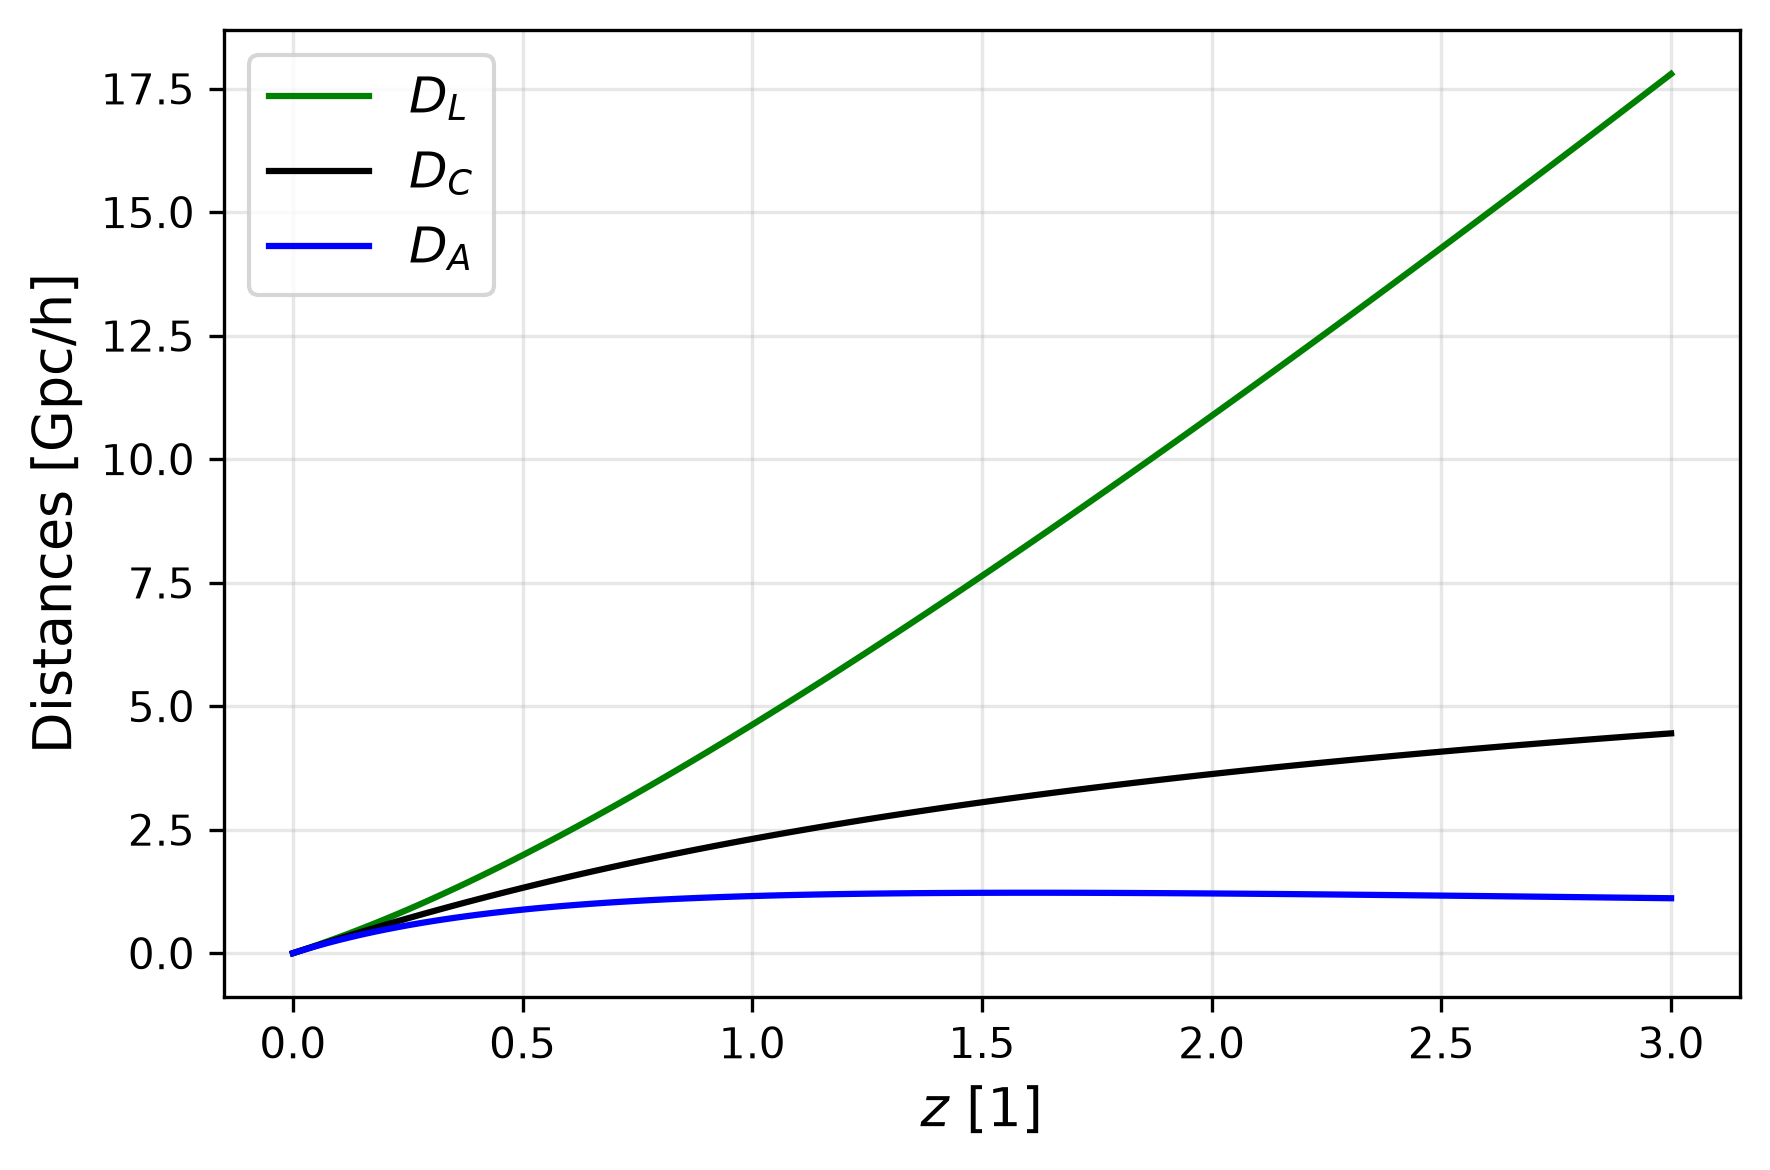

In [200]:
da_arr = dc_arr / (1 + z_arr)
dl_arr = (1 + z_arr) * dc_arr

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(z_arr, dl_arr, "g-", lw=1.5, label=r"$D_L$")
plt.plot(z_arr, dc_arr, "k-", lw=1.5, label=r"$D_C$")
plt.plot(z_arr, da_arr, "b-", lw=1.5, label=r"$D_A$")
plt.legend(fontsize=12)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel("Distances [Gpc/h]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Se puede hacer uso de `np.argmax` para averiguar el índice del valor de $z$ que genera el máximo de $D_A(z)$. De la gráfica de las distancias se puede observar que el máximo debe estar entre el $z = 1$ y $z = 2$.

In [201]:
z_approx = np.linspace(1, 2, 500)
z_max = np.argmax([simpson(idc, 0, z, steps) / (1 + z) for z in z_approx])
print(f"z_max = {z_approx[z_max]:.4f}")

z_max = 1.6052


El valor aproximado del máximo de $D_A$ está alrededor del $z_\text{max} \approx 1.6052$.

### 3.1. Why do we need different distances

No, su tamaño angular no va a decrecer siempre. Ya que $D_A$ presenta tanto un crecimiento como un decaimiento, entonces $\theta(z)$ va a adaptarse según sea el caso y lo que si va a llegar a tener es un tamaño angular aparente mínimo.

Por otro lado, como $D_A(z)$ toca el $0$ en $z = 0$, entonces no está permitido el *binning* anterior de `z_arr` y en su lugar se debe generar uno nuevo, `zp_arr`, para evitar errores numéricos. Además, $[D_A] = \mathrm{Gpc\, h^{-1}}$ y $[L] = \mathrm{kpc}$, por lo que se debe colocar en el mismo orden para realizar la operación. Lo más sencillo en este punto es considerar $L = 0.01\, \mathrm{Gpc}$.

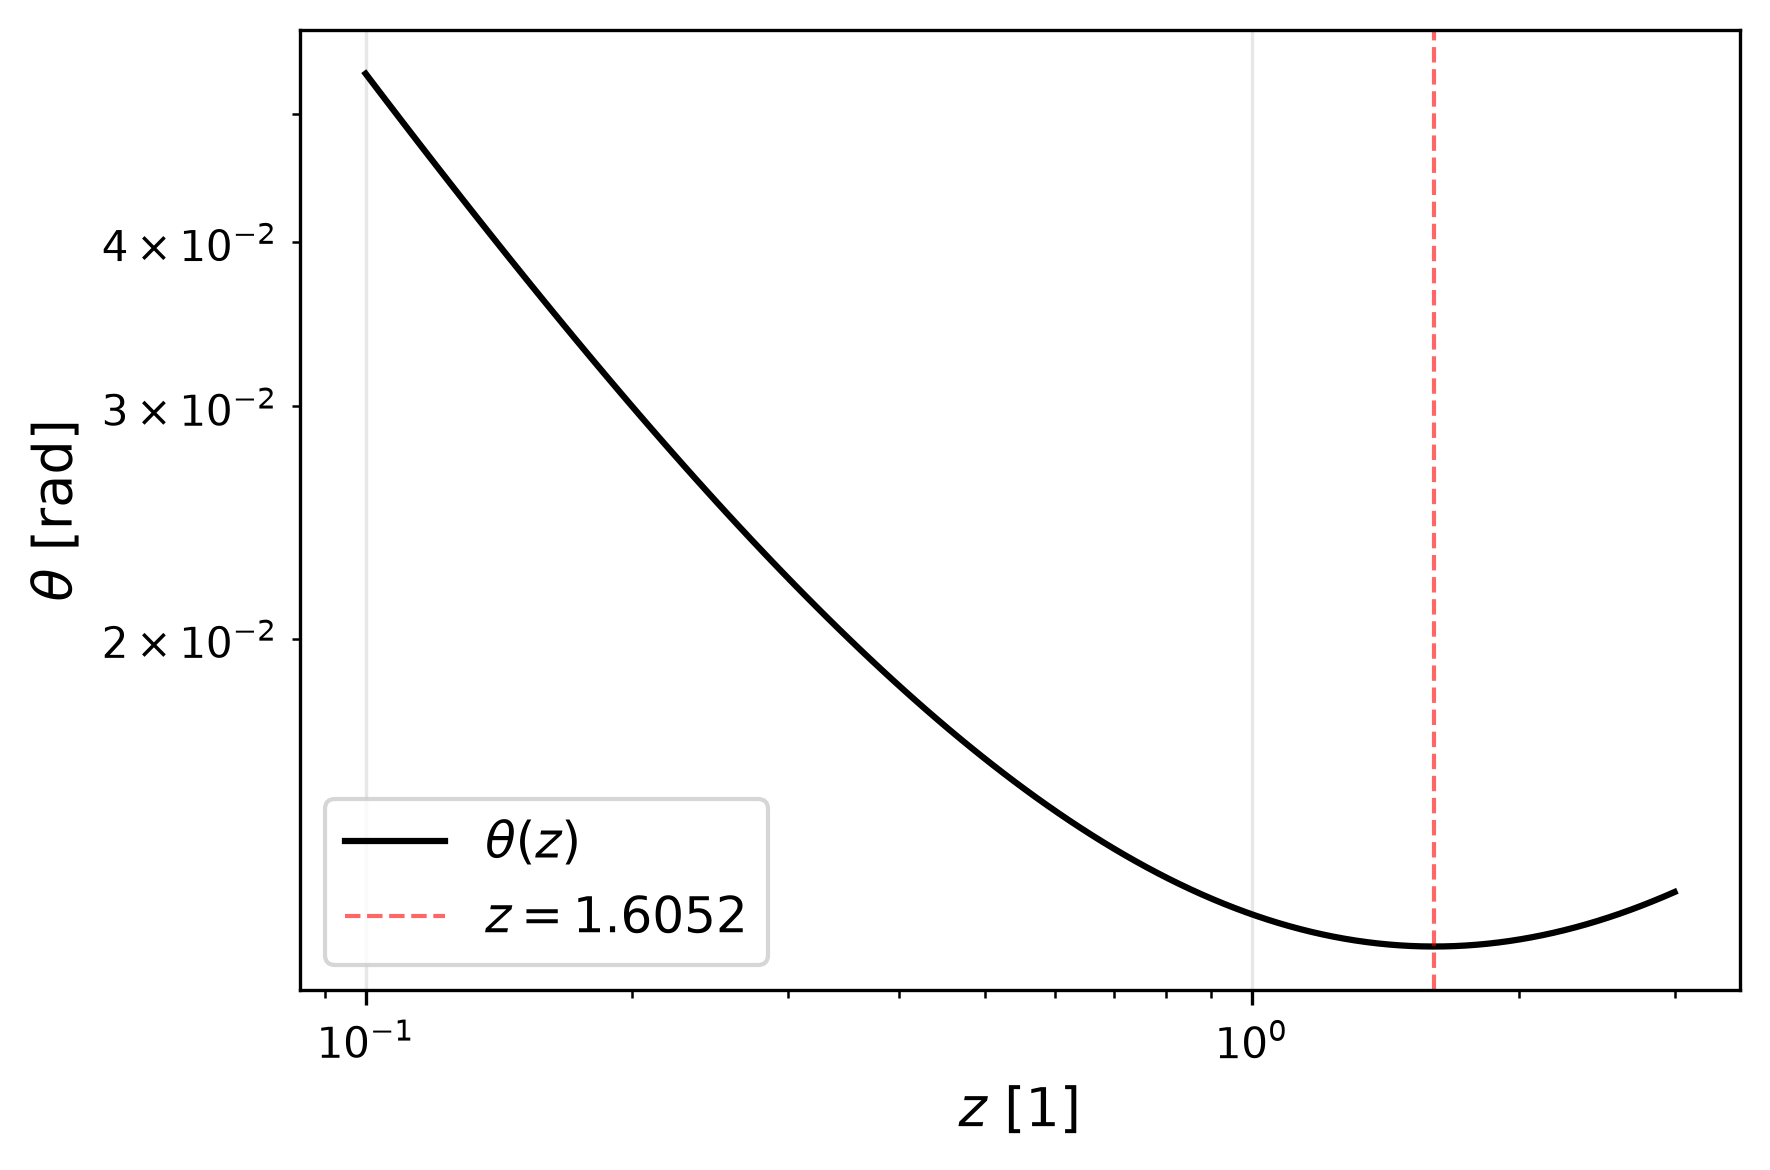

In [202]:
def theta(z):
    L = 0.01 # Gpc
    n = (1 + z) * L
    d = h * simpson(idc, 0, z, steps)
    return n / d

zp_arr = np.geomspace(0.1, 3, 120)
theta_arr = np.array([theta(z) for z in zp_arr])

plt.figure(figsize=(6, 4), dpi=300)
plt.loglog(zp_arr, theta_arr, "k-", lw=1.5, label=r"$\theta(z)$")
plt.axvline(x=1.6052, color="r", ls="--", lw=1, alpha=0.6, label=r"$z = 1.6052$")
plt.legend(fontsize=12)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel(r"$\theta$ [rad]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [203]:
z_approx = np.linspace(1, 2, 500)
z_max = np.argmin([theta(z) for z in z_approx])
print(f"z_min = {z_approx[z_max]:.4f}")

z_min = 1.6052


Si se grafica $\theta(z)$ en `log-log`, el mínimo es más exagerado y se puede identificar con mayor facilidad. El truco anterior vuelve a funcionar en este lugar, encontrado que el mínimo se encuentra alrededor de $z_\text{min} \approx 1.6052$.

Las matemáticas son claras: la definición de $D_A(z)$ da paso a que tenga un máximo y por ende $\theta(z) \propto D_A^{-1}(z)$ tiene un mínimo. Esto significa que existen galaxias con el mismo tamaño transversal físico en el momento de la emisión, pero a distintas épocas que medimos con el mismo tamaño aparente. Lo que se me ocurre es lo siguiente:

Para aquellas galaxias por encima de $z \approx 1.6$, las galaxias emitieron rayos de luz cruzados de modo que la expasión del universo separó el cruce a lo largo del viaje hasta que, cuando llegaron a nosotros, coincidieron en un solo punto.

![explanation](explanation.png)

### 3.2. A luminosity-distance observer

Ambos observadores están corrigiendo la expansión del universo pero centrandoce en cosas diferentes. Mientras que el observador que mide distancias angulares está calculando la distancia física corrigiendo la distancia comóvil con un factor de escala, $D_A(z) = D_C(z)/(1 + z)$, el observador que mide flujos está corrigiendo la pérdida de energía de los fotones que le llegan:

\begin{equation}
    L = \frac{L_{gal}}{(1 + z)^2},
\end{equation}

debido a que $[L] = \mathrm{W\, m^{-2}\, Hz^{-1}}$, mientras que continua midiendo la distancia de emisión con la distancia comóvil tal que:

\begin{equation}
    F = \frac{L}{4\pi D_C^2} = \frac{L_\text{gal}}{4\pi D_L^2(z)},
\end{equation}

donde $D_L(z) = (1 + z)D_C(z)$.

Obtienen valores distintos porque están haciendo correcciones a distintas cosas para distintos propósito y por eso obtienen formas funcionales de sus respectivas distancias diferentes.

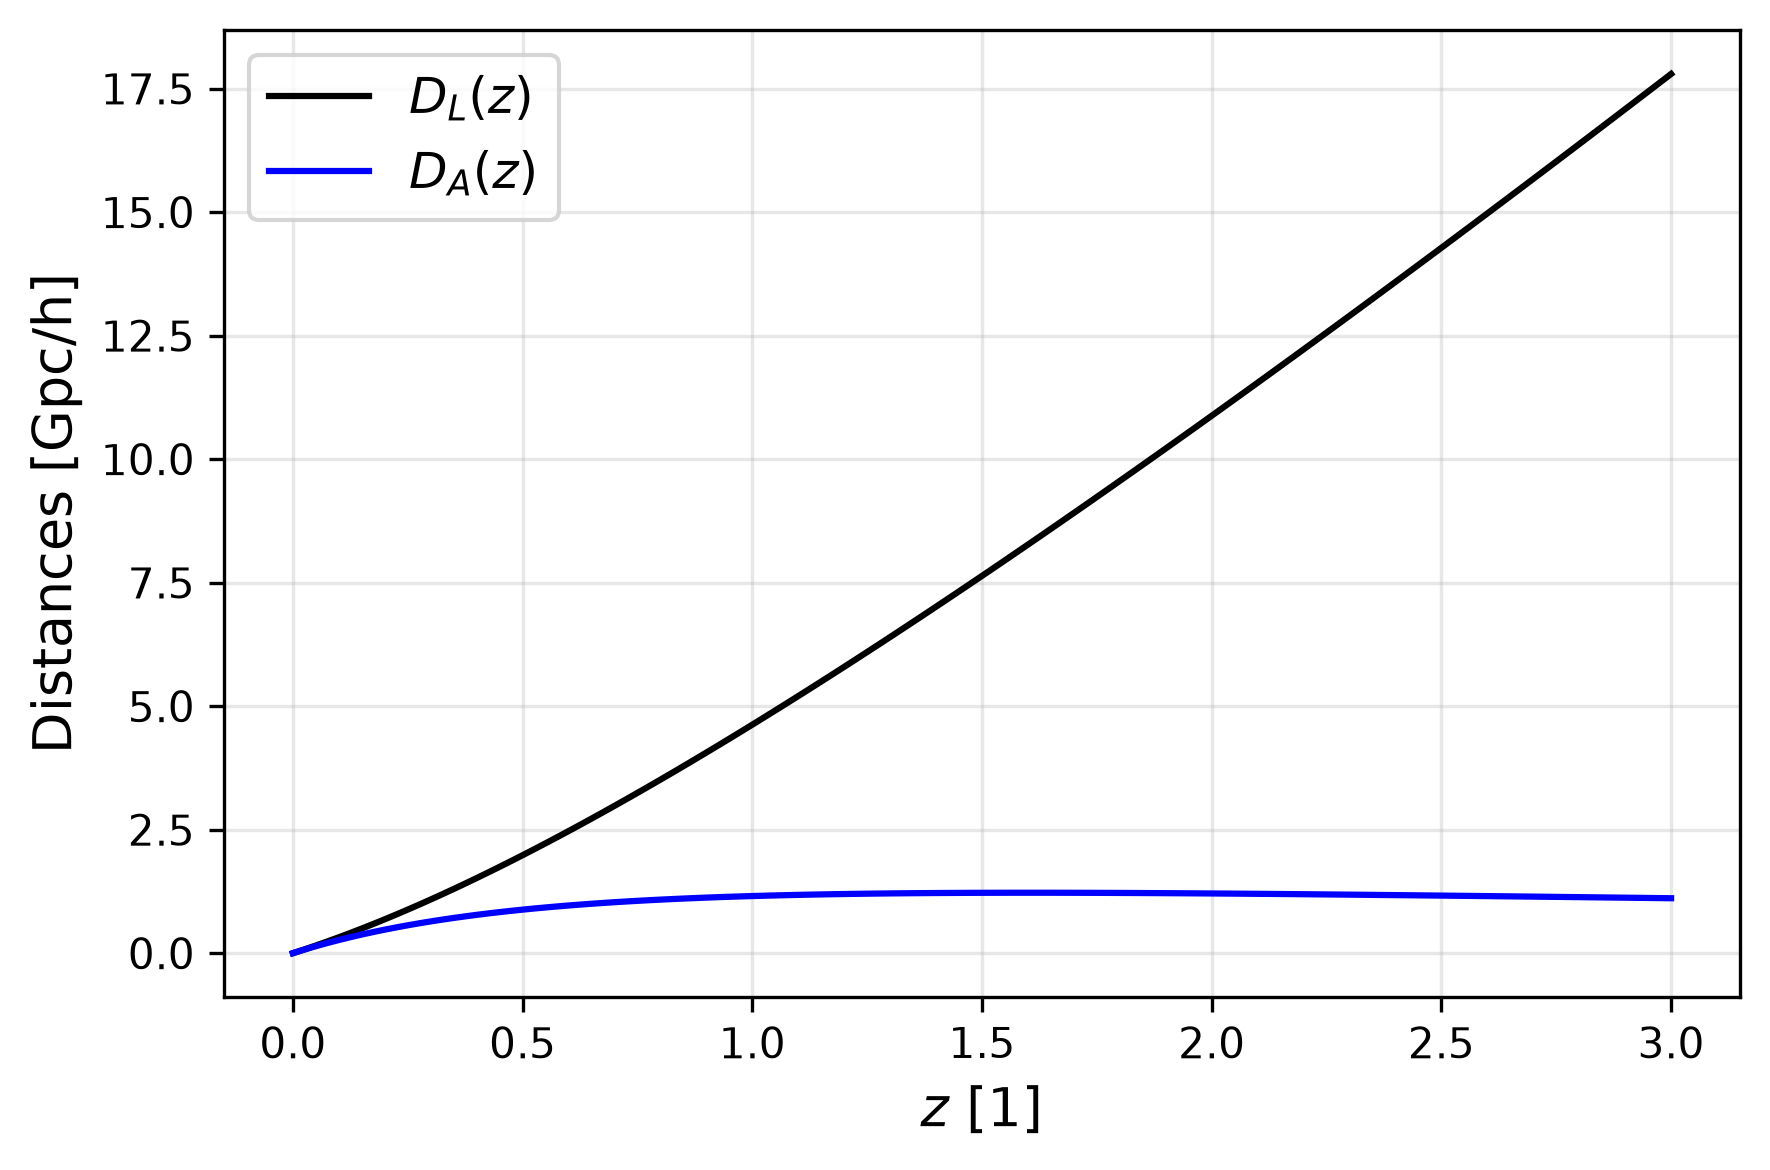

In [204]:
plt.figure(figsize=(6, 4), dpi=300)
plt.plot(z_arr, dl_arr, "k-", lw=1.5, label=r"$D_L(z)$")
plt.plot(z_arr, da_arr, "b-", lw=1.5, label=r"$D_A(z)$")
plt.legend(fontsize=12)
plt.xlabel(r"$z$ [1]", fontsize=13)
plt.ylabel("Distances [Gpc/h]", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. What happened to the Universe while the pothon was travelling?

1. Sabemos que $\Omega_i = \rho_i/\rho_c$, donde $\rho_c = 3H^2/8\pi G$, por lo que

\begin{equation}
    \rho_{M,0}\, a^{-3} = \rho_{\Lambda,0} \quad \Rightarrow \quad a_\text{eq}^{M,\Lambda} = \sqrt[3]{\frac{\Omega_{M,0}}{\Omega_{\Lambda,0}}} \approx 0.753947 \quad \Rightarrow \quad z_\text{eq}^{M,\Lambda} = \frac{1}{a_\text{eq}^{M,\Lambda}} - 1 \approx 0.326352.
\end{equation}

In [205]:
print(f"tLB: {simpson(itLB, 0, 0.326352, steps):.4f}")

tLB: 3.6565


El *lookback time* para este momento es: $t_\text{LB}\left(z_\text{eq}^{M,\Lambda}\right) \approx 3.6565\, \mathrm{Gyr}.$

1. Sabemos que $\Omega_M \propto (1 + z)^{3}$ y $\Omega_\Lambda$ es constante, entonces $\Omega_M$ crece conforme crece $z$, es decir, para tiempos tardíos (pasados lejanos a hoy en día) $\Omega_M$ domina, en particular para $z = 3$.
2. Sí, si el fotón fue emitido en $z = 3$, entonces vivió la igualdad $\mathrm{matería}-\Lambda$ mientras viajaba hasta nuestros días $z = 0$.
3. No, las densidades son promedios sobre ciertos volúmenes del universo, es decir, aunque la transición entre las densidades sí es instantáneo, físicamente existe un transitorio entre regiones locales del universo.

## 5. A photon from the early Universe

### 5.1. Cosmological archaeology

De forma similar al calculo anterior, se tiene que:

\begin{align}
    \rho_{M,0}\, a^{-3} &= \rho_{R,0}\, a^{-4} \quad &\Rightarrow a_\text{eq}^{M,R} &= \frac{\Omega_{R,0}}{\Omega_{M,0}} \approx 0.000333 \quad &\Rightarrow z_\text{eq}^{M,R} &= \frac{1}{a_\text{eq}^{M,R}} - 1 \approx 2998, \\
    \rho_{M,0}\, a^{-3} &= \rho_{\Lambda,0} \quad &\Rightarrow a_\text{eq}^{M,\Lambda} &= \sqrt[3]{\frac{\Omega_{M,0}}{\Omega_{\Lambda,0}}} \approx 0.753864 \quad &\Rightarrow z_\text{eq}^{M,\Lambda} &= \frac{1}{a_\text{eq}^{M,\Lambda}} - 1 \approx 0.326500.
\end{align}

In [ ]:
Om0 = 0.2999
Ol0 = 0.7
Or0 = 0.0001

print(f"tLB_MR: {simpson(itLB, 0, 2998, steps):.4f}")
print(f"tLB_ML: {simpson(itLB, 0, 0.3265, steps):.4f}")

tLB_MR: 13.4666
tLB_ML: 3.6580


Los *lookback times* para estos dos momentos son: 

\begin{align}
    t_\text{LB}\left(z_\text{eq}^{M,R}\right) &\approx 13.4651\, \mathrm{Gyr}, \\
    t_\text{LB}\left(z_\text{eq}^{M,\Lambda}\right) &\approx 3.6578\, \mathrm{Gyr}.
\end{align}

Observando el comportamiento del *redshift*, $z_\text{em} = 10^4 > z_\text{eq}^{M,R} > z_\text{eq}^{M,\Lambda}$, se concluye que un fotón emitido en $z_\text{em} = 10^4$ debe haber vivido tanto la igualdad $\mathrm{materia}-\Lambda$ como la $\mathrm{materia}-\mathrm{radiación}$.

## 6. Evolution of matter density with cosmic time

Sabemos que $H(a) = \dot{a}/a$, entonces

\begin{equation}
    \mathrm{d}t = \frac{\mathrm{da}}{aH(a)} = \frac{\mathrm{d}a}{aH_0\sqrt{\Omega_{R,0}a^{-4} + \Omega_{M,0}a^{-3} + \Omega_{\Lambda,0}}}.
\end{equation}

En los pasados lejanos a hoy en día, la $\Lambda$ dominaba, después hubo una época donde dominaba la materia y, finalmente, la radiación. La solución a la ecuación anterior, desde la emisión hasta la observación de un rayo de luz, para cada una de éstas épocas son, respectivamente:

\begin{align}
    t &= \frac{\log{a}}{H_0\sqrt{\Omega_{\Lambda,0}}} \quad &\Rightarrow \quad a(t) &= \exp\left(H_0\sqrt{\Omega_{\Lambda,0}}\, t\right), \\
    t &= \frac{2}{3H_0\sqrt{\Omega_{M,0}a^{-3}}} \quad &\Rightarrow \quad a(t) &= \left(\frac{3H_0\sqrt{\Omega_{M,0}}}{2}\right)^{2/3}\, t^{2/3}, \\
    t &= \frac{1}{2H_0\sqrt{\Omega{R,0}a^{-4}}} \quad &\Rightarrow \quad a(t) &= \left(2H_0\sqrt{\Omega_{R,0}}\right)^{1/2}\, t^{1/2}.
\end{align}

En particular, la relación $\rho_M = \rho_{M,0}a^{-3}$ implica que la evolución de esta componente en cada época es:

\begin{equation}
    \rho_M(t) =
    \begin{cases}
        \left(3H_0^2\, \Omega_{M,0}\ /\ 8\pi G\right)\, \mathrm{e}^{-3H_0\sqrt{\Omega_{\Lambda,0}}\, t}, & z_\text{eq}^{M,\Lambda} < z, \\
        \left(6\pi G\, t^2\right)^{-1}, & z_\text{eq}^{M,R} < z < z_\text{eq}^{M,\Lambda}, \\
        \left(3H_0^2\, \Omega_{M,0}\ /\ 8\pi G\right)\, \left(2H_0\sqrt{\Omega_{R,0}}\right)^{-3/2}\, t^{-3/2}, & z < z_\text{eq}^{M,R}.        
    \end{cases}
\end{equation}

1. Las gráficas en `log-log` consisten en sacar el logaritmo a ambos lados de la expresión a graficar, por lo que, durante la era de radiación, la pendiente debe ser $-3/2$, es decir, una linea recta con pendiente negativa.
2. Para la materia ocurre algo similar, pero la pendiente cambia a $-2$.
3. Cuando $\Lambda$ domina, lo que esperaría ver sería una línea casi horizontal con una pendiente negativa muy suave.

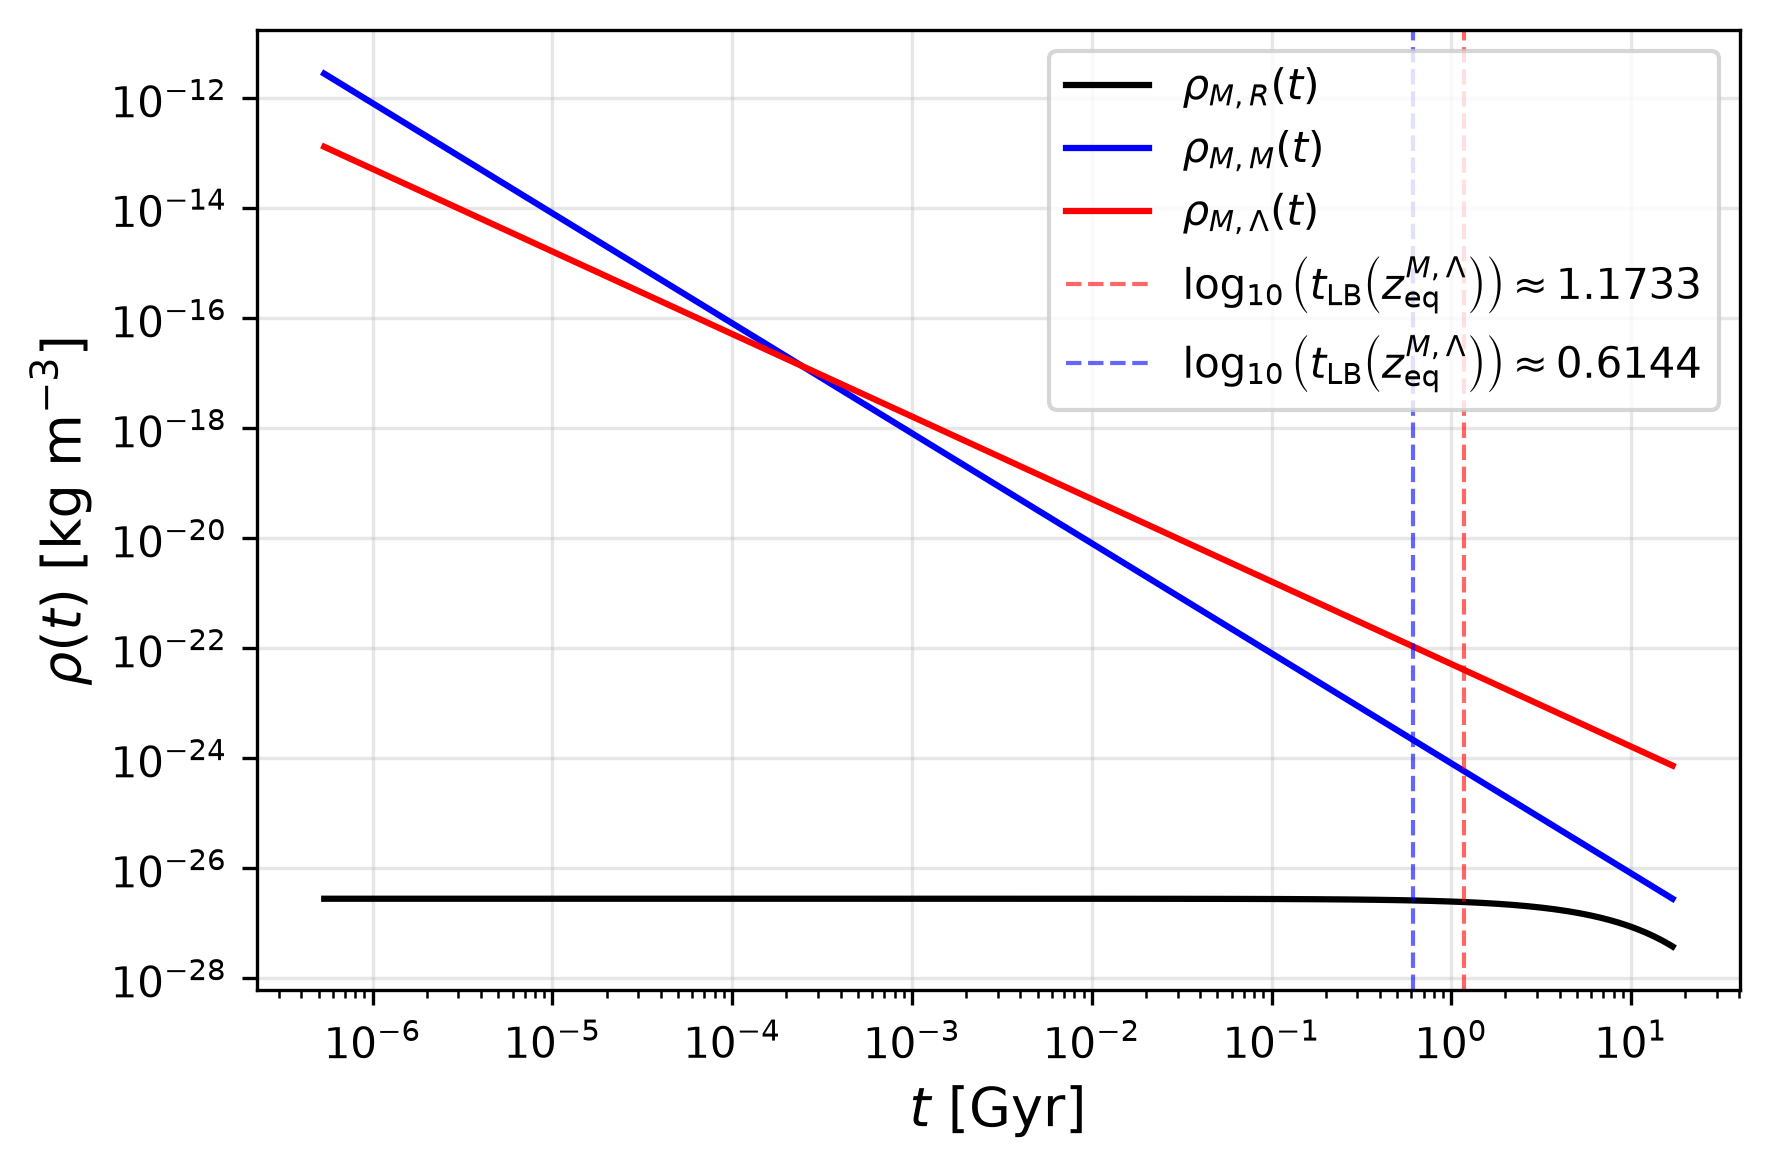

In [229]:
def t(z):
    ftr = 3 * H0 * np.sqrt(Om0) / 2 # [H0] = Gyr-1
    d = ftr * (1 + z) ** (3/2)
    return 1 / d

def rhom(t, era):
    G = 6.6468e22 # m3 kg-1 Gyr-2

    if era == "radiation":
        n = 3 * H0 ** 2 * Om0 * np.exp(-3 * H0 * np.sqrt(Om0) * t)
        d = 8 * np.pi * G
    elif era == "matter":
        n = 1
        d = 6 * np.pi * G * t ** 2
    elif era == "lambda":
        n = 3 * H0 ** 2 * Om0
        d= 8 * np.pi * G * (2 * H0 * np.sqrt(1e-4) * t) ** (3/2)

    return n / d

t_arr = t(np.geomspace(0.0001, 10e4, 120))
rhomr_arr = rhom(t_arr, "radiation")
rhomm_arr = rhom(t_arr, "matter")
rhoml_arr = rhom(t_arr, "lambda")

plt.figure(figsize=(6, 4), dpi=300)
plt.loglog(t_arr, rhomr_arr, "k-", lw=1.5, label=r"$\rho_{M,R}(t)$")
plt.loglog(t_arr, rhomm_arr, "b-", lw=1.5, label=r"$\rho_{M,M}(t)$")
plt.loglog(t_arr, rhoml_arr, "r-", lw=1.5, label=r"$\rho_{M,\Lambda}(t)$")
plt.xlabel(r"$t$ [Gyr]", fontsize=13)
plt.ylabel(r"$\rho(t)$ [kg m$^{-3}$]", fontsize=13)
plt.axvline(x=np.log10(14.9091), color="r", ls="--", lw=1, alpha=0.6, label=rf"$\log_{{10}}\left(t_\text{{LB}}\left(z_\text{{eq}}^{{M,\Lambda}}\right)\right) \approx {np.log10(14.9035):.4f}$")
plt.axvline(x=np.log10(4.1160), color="b", ls="--", lw=1, alpha=0.6, label=rf"$\log_{{10}}\left(t_\text{{LB}}\left(z_\text{{eq}}^{{M,\Lambda}}\right)\right) \approx {np.log10(4.1150):.4f}$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical and physical checks

1. El primer trozo de código a comprobar es si el método de integración numérica está bien implementado. Como este es un método numérico, los dos *checks* que se me ocurren son:
**a)** utilizar otro método numérico para ver si coinciden y **b)** importar de `scipy` algún método de integración numérica y replicar el resultado.
La idea es elegir algo muy conocido, yo voy a elegir 

\begin{equation}
    \int_0^\pi\mathrm{d}x\, \sin x = 2
\end{equation}

In [208]:
from scipy.integrate import quad

def riemann(f, a, b, n):
    """
    Parameters:
        f: function to integrate
        a: lower limit of integration
        b: upper limit of integration
        n: number of subintervals
    """
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    S = np.sum(y[:-1]) * h
    return S

y = simpson(np.sin, 0, np.pi, steps)
y1 = riemann(np.sin, 0, np.pi, steps)
y2, _ = quad(np.sin, 0, np.pi)

print(f'riemann - simpson: {y1 - y:.4f}')
print(f'scipy - simpson: {y2 - y:.4f}')

riemann - simpson: -0.0000
scipy - simpson: 0.0000


2. Para comprobar que el *lookback time* está correcto se me ocurre calcular el tiempo de CMB que conocemos ahora, ya que la primer cosmología dada está más o menos cerca de los datos actuales, así que esperaría un valor de $t_\text{LB}$ parecido.

## AI-use statement

He utilizado AI a lo largo de toda la práctica para hacerle preguntas puntuales sobre el funcionamiendo de `numpy` y `matplotlib`, pedirle que haga cuentas, conversiones de unidades, formateo de gráficas y consejos. Revisé todas las conversiones de unidades con calculadora, pero las preguntas sobre *python* o funcionaban o hubiera sido claro que algo estaba mal. Por último, al estar en *vscode* y tener activada la opción de *copilot*, me ha autocompletado las funciones de `simpson` y `riemann` y algunas otras cosas repetitivas, me hiz falta hacer unas pocas correcciones en la primera.

Agrego mi historial de *opencode* por si se quiere revisar: https://opncd.ai/share/6PLbCUg0